In [11]:
with open('data/LogHub_merged_50k.log', 'r', encoding="utf-8", errors="ignore") as f:
    lines = [line.strip() for line in f if line.strip()]
print("После удаления пустых строк:", len(lines))
print(lines[:5])

После удаления пустых строк: 2000
['081109 203615 148 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_38865049064139660 terminating', '081109 203807 222 INFO dfs.DataNode$PacketResponder: PacketResponder 0 for block blk_-6952295868487656571 terminating', '081109 204005 35 INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.73.220:50010 is added to blk_7128370237687728475 size 67108864', '081109 204015 308 INFO dfs.DataNode$PacketResponder: PacketResponder 2 for block blk_8229193803249955061 terminating', '081109 204106 329 INFO dfs.DataNode$PacketResponder: PacketResponder 2 for block blk_-6670958622368987959 terminating']


In [12]:
import re
import pandas as pd

LOG_PATH = "data/LogHub_merged_50k.log"

if "lines" in globals() and isinstance(lines, list) and lines:
    raw_lines = lines
else:
    with open(LOG_PATH, "r", encoding="utf-8", errors="ignore") as f:
        raw_lines = [line.rstrip("\n") for line in f if line.strip()]


def parse_hdfs_log_line(line: str) -> dict:
    """Формат: YYMMDD HHMMSS PID LEVEL component: message"""
    m = re.match(
        r"^(\d{6})\s+(\d{6})\s+(\d+)\s+(INFO|WARN|ERROR|DEBUG|FATAL)\s+(.+)$",
        line,
    )
    if not m:
        return {
            "date": None,
            "time": None,
            "pid": None,
            "level": None,
            "component": None,
            "message": line,
            "parse_ok": False,
        }
    date, time, pid, level, rest = m.groups()
    if ": " in rest:
        comp, msg = rest.split(": ", 1)
    else:
        idx = rest.find(":")
        if idx != -1:
            comp, msg = rest[:idx], rest[idx + 1 :].lstrip()
        else:
            comp, msg = rest, ""
    return {
        "date": date,
        "time": time,
        "pid": int(pid),
        "level": level,
        "component": comp,
        "message": msg,
        "parse_ok": True,
    }


df = pd.DataFrame([parse_hdfs_log_line(ln) for ln in raw_lines])

print("Файл:", LOG_PATH)
print("Строк в датасете:", len(df))
print()
print("Распределение по уровню лога:")
print(df["level"].value_counts(dropna=False).to_string())
print()
print("Первые 15 записей (таблица):")
display(
    df[["date", "time", "pid", "level", "component", "message"]]
    .head(15)
    .style.set_properties(**{"text-align": "left"})
    .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}])
)

Файл: data/HDFS_2k.log
Строк в датасете: 2000

Распределение по уровню лога:
level
INFO    1920
WARN      80

Первые 15 записей (таблица):


,date,time,pid,level,component,message
0,081109,203615,148,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_38865049064139660 terminating
1,081109,203807,222,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_-6952295868487656571 terminating
2,081109,204005,35,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.73.220:50010 is added to blk_7128370237687728475 size 67108864
3,081109,204015,308,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_8229193803249955061 terminating
4,081109,204106,329,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_-6670958622368987959 terminating
5,081109,204132,26,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.43.115:50010 is added to blk_3050920587428079149 size 67108864
6,081109,204324,34,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.203.80:50010 is added to blk_7888946331804732825 size 67108864
7,081109,204453,34,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.250.11.85:50010 is added to blk_2377150260128098806 size 67108864
8,081109,204525,512,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_572492839287299681 terminating
9,081109,204655,556,INFO,dfs.DataNode$PacketResponder,Received block blk_3587508140051953248 of size 67108864 from /10.251.42.84


In [13]:
import numpy as np

# --- Обогащаем датафрейм: нормализуем время, извлекаем сущности из message ---

def _to_dt_2008_ymd_hms(date_yyMMdd: str, time_hhmmss: str):
    if not date_yyMMdd or not time_hhmmss:
        return pd.NaT
    yy = int(date_yyMMdd[:2])
    mm = int(date_yyMMdd[2:4])
    dd = int(date_yyMMdd[4:6])
    hh = int(time_hhmmss[:2])
    mi = int(time_hhmmss[2:4])
    ss = int(time_hhmmss[4:6])
    # В этом датасете принято YY=08 (HDFS public logs). Подставляем 2000+YY.
    return pd.Timestamp(year=2000 + yy, month=mm, day=dd, hour=hh, minute=mi, second=ss)


df = df.copy()
df["ts"] = [
    _to_dt_2008_ymd_hms(d, t) for d, t in zip(df["date"].astype(str), df["time"].astype(str))
]

# block id
blk_re = re.compile(r"\bblk_(-?\d+)\b")
df["block_id"] = df["message"].str.extract(blk_re, expand=False)

# размер (если есть)
size_re = re.compile(r"\bsize\s+(\d+)\b")
df["size"] = pd.to_numeric(df["message"].str.extract(size_re, expand=False), errors="coerce")

# src / dest IP (часто встречаются в DataXceiver)
ip_re = re.compile(r"/(\d{1,3}(?:\.\d{1,3}){3})")
df["src_ip"] = df["message"].str.extract(re.compile(r"\bsrc:\s*/(\d{1,3}(?:\.\d{1,3}){3})"), expand=False)
df["dest_ip"] = df["message"].str.extract(re.compile(r"\bdest:\s*/(\d{1,3}(?:\.\d{1,3}){3})"), expand=False)
df["any_ip"] = df["message"].str.extract(ip_re, expand=False)

# тип события (грубая классификация по ключевым фразам)
patterns = [
    ("warn_exception_serving", r"Got exception while serving"),
    ("block_received", r"\bReceived block\b"),
    ("block_receiving", r"\bReceiving block\b"),
    ("block_served", r"\bServed block\b"),
    ("allocate_block", r"NameSystem\.allocateBlock"),
    ("add_stored_block", r"NameSystem\.addStoredBlock"),
    ("packet_responder_terminating", r"PacketResponder .* terminating"),
    ("verification_succeeded", r"Verification succeeded"),
    ("deleting_block", r"\bDeleting block\b"),
]

def classify_event(msg: str) -> str:
    if msg is None:
        return "unknown"
    for name, pat in patterns:
        if re.search(pat, msg):
            return name
    return "other"


df["event_type"] = df["message"].apply(classify_event)

print("Уникальных типов событий:", df["event_type"].nunique())
print(df["event_type"].value_counts().to_string())
print()
print("Примеры для каждого типа:")
display(
    df.sort_values(["event_type", "ts"], na_position="last")
    .groupby("event_type", as_index=False)
    .head(1)[["event_type", "level", "component", "message"]]
    .reset_index(drop=True)
)

# --- Что считается 'нормальным', а что потенциально 'аномальным' ---
# Нормальные события: потоковая работа с блоками и метаданными
normal_event_types = {
    "block_received",
    "block_receiving",
    "block_served",
    "allocate_block",
    "add_stored_block",
    "packet_responder_terminating",
    "verification_succeeded",
}

# Потенциальные аномалии: WARN/exception, удаление блоков, нестандартные размеры
anomaly_mask = (
    (df["level"] == "WARN")
    | (df["event_type"].isin({"warn_exception_serving", "deleting_block"}))
    | (df["size"].notna() & (df["size"] != 67108864))
)

anomalies = df[anomaly_mask].copy()
print("Потенциальных аномалий:", len(anomalies))
print("Топ причин (по event_type):")
print(anomalies["event_type"].value_counts().to_string())
print()

# Покажем аномалии (20 строк) с максимумом полезных полей
cols = ["ts", "level", "component", "event_type", "block_id", "size", "src_ip", "dest_ip", "message"]
display(anomalies[cols].sort_values("ts").head(20))

print("\nНормальные события (доля):")
print(
    (df["event_type"].isin(normal_event_types).mean() * 100).round(2),
    "% строк относятся к базовым нормальным типам",
)

print("\nТоп-15 самых частых событий (как 'норма'):")
display(
    df[df["event_type"].isin(normal_event_types)][["event_type", "component", "message"]]
    .head(15)
)

# --- Дополнительные 'аномалии' по статистике ---
# 1) Редкие компоненты
print("\nРедкие компоненты (<=2 появления):")
rare_components = df["component"].value_counts()
rare_components = rare_components[rare_components <= 2]
display(rare_components)

# 2) Нестандартные размеры блоков (в этом датасете нормален 64MiB = 67108864)
print("\nНестандартные размеры (если есть):")
display(df[df["size"].notna() & (df["size"] != 67108864)][["ts", "level", "event_type", "block_id", "size", "message"]].head(30))

# 3) Кто чаще всего в WARN/exception (по IP)
print("\nТоп IP в WARN/exception:")
display(
    anomalies["any_ip"].value_counts().head(15)
)


Уникальных типов событий: 10
event_type
add_stored_block                314
packet_responder_terminating    311
block_received                  294
block_receiving                 292
deleting_block                  263
other                           231
allocate_block                  115
block_served                     80
warn_exception_serving           80
verification_succeeded           20

Примеры для каждого типа:


,event_type,level,component,message
0,add_stored_block,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...
1,allocate_block,INFO,dfs.FSNamesystem,BLOCK* NameSystem.allocateBlock: /user/root/ra...
2,block_received,INFO,dfs.DataNode$PacketResponder,Received block blk_3587508140051953248 of size...
3,block_receiving,INFO,dfs.DataNode$DataXceiver,Receiving block blk_5792489080791696128 src: /...
4,block_served,INFO,dfs.DataNode$DataXceiver,10.251.194.213:50010 Served block blk_-7724713...
5,deleting_block,INFO,dfs.FSDataset,Deleting block blk_1781953582842324563 file /m...
6,other,INFO,dfs.FSNamesystem,BLOCK* NameSystem.delete: blk_2568309208894455...
7,packet_responder_terminating,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_38865049064139...
8,verification_succeeded,INFO,dfs.DataBlockScanner,Verification succeeded for blk_-49809165198942...
9,warn_exception_serving,WARN,dfs.DataNode$DataXceiver,10.251.30.85:50010:Got exception while serving...


Потенциальных аномалий: 378
Топ причин (по event_type):
event_type
deleting_block            263
warn_exception_serving     80
add_stored_block           20
block_received             15



,ts,level,component,event_type,block_id,size,src_ip,dest_ip,message
41,2008-11-09 21:08:12,INFO,dfs.DataNode$PacketResponder,block_received,-3909548841543565741,3542967.0,NaN,NaN,Received block blk_-3909548841543565741 of siz...
49,2008-11-09 21:14:03,INFO,dfs.FSNamesystem,add_stored_block,2113880130496815041,3549917.0,NaN,NaN,BLOCK* NameSystem.addStoredBlock: blockMap upd...
72,2008-11-09 21:38:37,INFO,dfs.FSDataset,deleting_block,1781953582842324563,NaN,NaN,NaN,Deleting block blk_1781953582842324563 file /m...
77,2008-11-09 21:40:43,WARN,dfs.DataNode$DataXceiver,warn_exception_serving,-2918118818249673980,NaN,NaN,NaN,10.251.30.85:50010:Got exception while serving...
78,2008-11-09 21:44:02,WARN,dfs.DataNode$DataXceiver,warn_exception_serving,8376667364205250596,NaN,NaN,NaN,10.251.126.255:50010:Got exception while servi...
80,2008-11-09 21:45:29,WARN,dfs.DataNode$DataXceiver,warn_exception_serving,3763728533434719668,NaN,NaN,NaN,10.251.123.132:50010:Got exception while servi...
81,2008-11-09 21:49:10,WARN,dfs.DataNode$DataXceiver,warn_exception_serving,6241141267506413726,NaN,NaN,NaN,10.250.13.188:50010:Got exception while servin...
83,2008-11-09 21:51:36,WARN,dfs.DataNode$DataXceiver,warn_exception_serving,8466246428293623262,NaN,NaN,NaN,10.251.199.19:50010:Got exception while servin...
84,2008-11-09 21:52:59,WARN,dfs.DataNode$DataXceiver,warn_exception_serving,-3140754468249228022,NaN,NaN,NaN,10.250.9.207:50010:Got exception while serving...
85,2008-11-09 21:57:02,WARN,dfs.DataNode$DataXceiver,warn_exception_serving,3441699978641526775,NaN,NaN,NaN,10.251.202.134:50010:Got exception while servi...



Нормальные события (доля):
71.3 % строк относятся к базовым нормальным типам

Топ-15 самых частых событий (как 'норма'):


...

component
dfs.DataNode    1
Name: count, dtype: int64


Нестандартные размеры (если есть):


,ts,level,event_type,block_id,size,message
41,2008-11-09 21:08:12,INFO,block_received,-3909548841543565741,3542967.0,Received block blk_-3909548841543565741 of siz...
49,2008-11-09 21:14:03,INFO,add_stored_block,2113880130496815041,3549917.0,BLOCK* NameSystem.addStoredBlock: blockMap upd...
171,2008-11-10 00:21:03,INFO,block_received,-4067446915270471579,25933924.0,Received block blk_-4067446915270471579 of siz...
507,2008-11-10 10:43:21,INFO,add_stored_block,8894334107354324777,3549832.0,BLOCK* NameSystem.addStoredBlock: blockMap upd...
509,2008-11-10 10:44:01,INFO,add_stored_block,4802366409699286298,3547304.0,BLOCK* NameSystem.addStoredBlock: blockMap upd...
565,2008-11-10 11:19:58,INFO,add_stored_block,-2144263949276079479,3547172.0,BLOCK* NameSystem.addStoredBlock: blockMap upd...
583,2008-11-10 11:34:07,INFO,block_received,3242229894054064344,3540106.0,Received block blk_3242229894054064344 of size...
619,2008-11-10 11:59:34,INFO,block_received,-4433556521525567493,28492032.0,Received block blk_-4433556521525567493 of siz...
667,2008-11-10 12:32:37,INFO,add_stored_block,-8502460962248995911,28489733.0,BLOCK* NameSystem.addStoredBlock: blockMap upd...
672,2008-11-10 12:34:53,INFO,add_stored_block,-1435656632270396446,28490269.0,BLOCK* NameSystem.addStoredBlock: blockMap upd...



Топ IP в WARN/exception:


any_ip
10.251.195.33     2
10.250.11.100     2
10.250.7.96       2
10.251.203.246    2
10.251.214.130    2
10.251.38.197     2
10.251.195.52     2
10.251.30.179     2
10.251.31.85      2
10.250.15.198     2
10.251.203.179    2
10.250.15.240     2
10.250.13.188     2
10.250.19.227     2
10.251.90.64      1
Name: count, dtype: int64

## Шаг 1. Иллюстрации: распределения (EDA для модели критичности)

Перед признаками и нечёткой логикой полезно **увидеть фон**: как часто встречаются уровни (`INFO`/`WARN`) и **типы событий** (`event_type`).  
Ниже графики строятся по уже созданному `df` — **сначала выполните ячейки загрузки, парсинга и классификации `event_type`**.

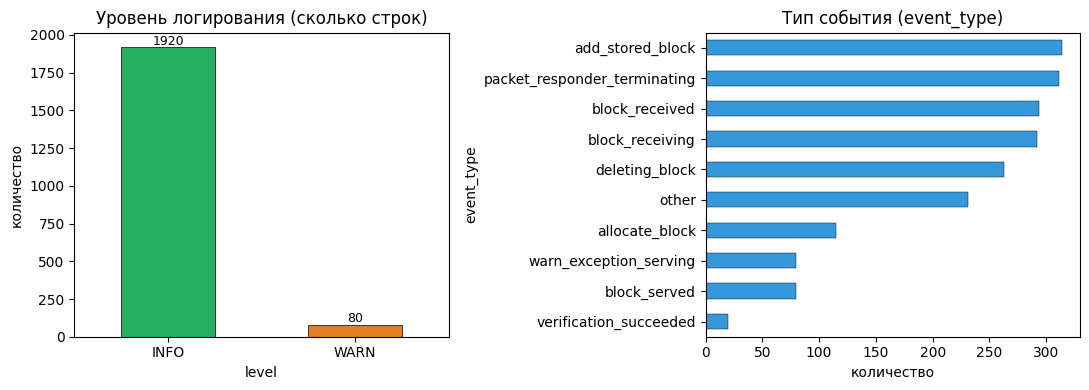

Доля WARN: 4.00%


In [14]:
import matplotlib.pyplot as plt

if "df" not in globals():
    raise RuntimeError("Выполните сначала ячейки выше: должен существовать DataFrame df.")
if "event_type" not in df.columns:
    raise RuntimeError("В ячейке с классификацией событий должен появиться столбец event_type.")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

vc_level = df["level"].value_counts()
colors_level = ["#27ae60" if x == "INFO" else "#e67e22" if x == "WARN" else "#c0392b" for x in vc_level.index]
vc_level.plot(kind="bar", ax=axes[0], color=colors_level, edgecolor="black", linewidth=0.5)
axes[0].set_title("Уровень логирования (сколько строк)")
axes[0].set_xlabel("level")
axes[0].set_ylabel("количество")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(vc_level.values):
    axes[0].text(i, v + 15, str(v), ha="center", fontsize=9)

vc_evt = df["event_type"].value_counts().sort_values(ascending=True)
vc_evt.plot(kind="barh", ax=axes[1], color="#3498db", edgecolor="black", linewidth=0.3)
axes[1].set_title("Тип события (event_type)")
axes[1].set_xlabel("количество")
plt.tight_layout()
plt.show()

print("Доля WARN:", f"{(df['level'] == 'WARN').mean() * 100:.2f}%")

## Шаг 2. Время и источники событий

Здесь смотрим **когда** события сгущаются во времени (по `ts`) и **кто** их пишет чаще всего (`component`). Это пригодится для контекстных признаков модели критичности (всплески, доля WARN в окне — позже).

Нужны столбцы `ts` и `component` из ячейки обогащения выше.

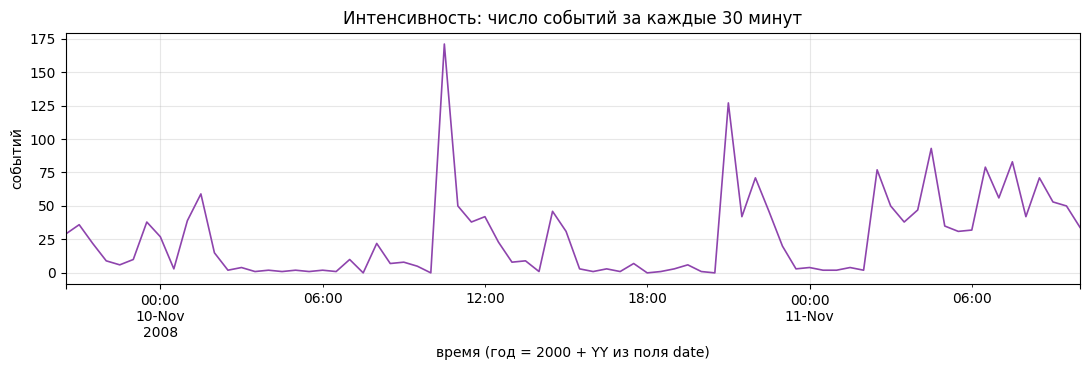

Интервал в данных: 2008-11-09 20:36:15 — 2008-11-11 10:20:17


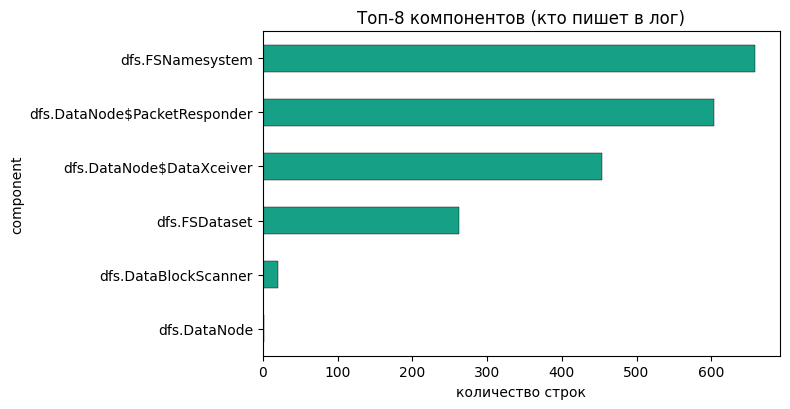

In [15]:
import matplotlib.pyplot as plt

if "df" not in globals():
    raise RuntimeError("Сначала выполните ячейки с загрузкой и парсингом.")
if "ts" not in df.columns:
    raise RuntimeError("Нужен столбец ts — выполните ячейку обогащения (дата/время из лога).")

df_time = df.dropna(subset=["ts"]).sort_values("ts")
if df_time.empty:
    print("Нет строк с валидным ts — график по времени пропущен.")
else:
    fig, ax = plt.subplots(figsize=(11, 3.8))
    counts = df_time.set_index("ts").resample("30min").size()
    counts.plot(ax=ax, color="#8e44ad", linewidth=1.2)
    ax.set_title("Интенсивность: число событий за каждые 30 минут")
    ax.set_ylabel("событий")
    ax.set_xlabel("время (год = 2000 + YY из поля date)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("Интервал в данных:", df_time["ts"].min(), "—", df_time["ts"].max())

fig, ax = plt.subplots(figsize=(8, 4.2))
df["component"].value_counts().head(8).sort_values(ascending=True).plot(
    kind="barh", ax=ax, color="#16a085", edgecolor="black", linewidth=0.3
)
ax.set_title("Топ-8 компонентов (кто пишет в лог)")
ax.set_xlabel("количество строк")
plt.tight_layout()
plt.show()

## Шаг 3. Признаки входа (MVP) для оценки критичности

Пять чисел в диапазоне **\[0, 1]** (удобно для функций принадлежности нечёткой логики):

| Признак | Смысл |
|--------|--------|
| `x_level` | жёсткость уровня лога (`INFO` ниже, `WARN` выше) |
| `x_kb_base` | **базовая** серьёзность по типу события из мини–БЗ (таблица ниже в коде) |
| `x_lex` | маркеры «плохих» слов в `message` (исключения и т.п.) |
| `x_ctx` | доля `WARN` среди **последних 100** событий по времени (контекст всплеска) |
| `x_param` | отклонение размера блока от типичного 64 MiB (`67108864`), если `size` известен |

После выполнения ячейки эти столбцы добавятся в `df`.

Описание признаков (0..1):


,count,mean,std,min,25%,50%,75%,max
x_level,2000.0,0.144000,0.117605,0.12,0.12,0.12,0.12,0.720000
x_kb_base,2000.0,0.161395,0.174468,0.04,0.08,0.12,0.15,0.950000
x_lex,2000.0,0.040000,0.196008,0.00,0.00,0.00,0.00,1.000000
x_ctx,2000.0,0.040086,0.070620,0.00,0.00,0.00,0.07,0.260000
x_param,2000.0,0.013571,0.104705,0.00,0.00,0.00,0.00,0.947399


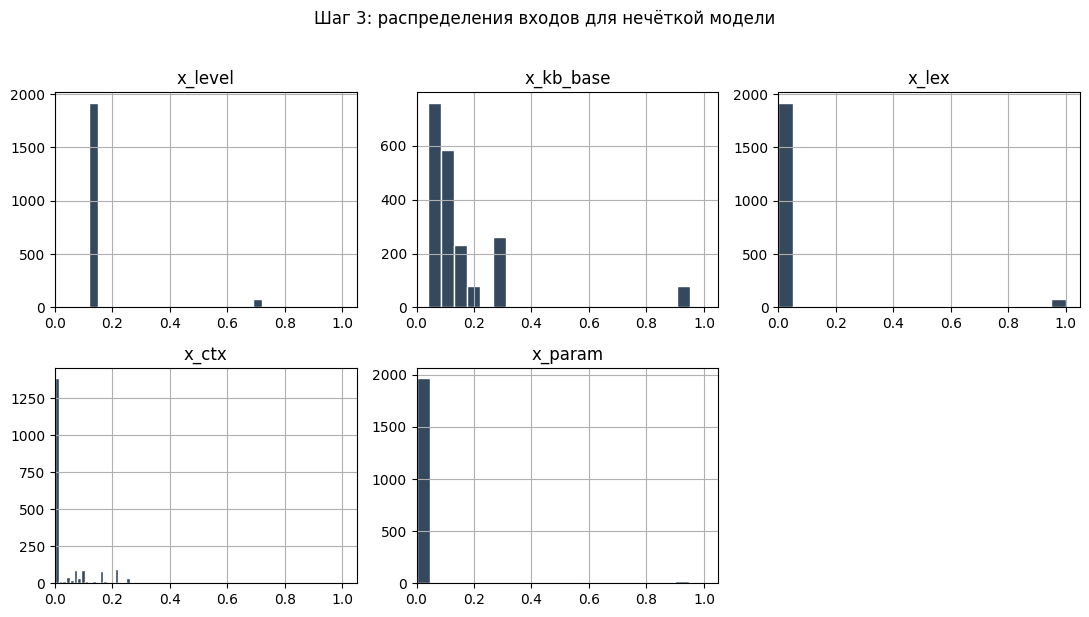

In [16]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "df" not in globals():
    raise RuntimeError("Сначала выполните ячейки с df.")
if "event_type" not in df.columns:
    raise RuntimeError("Нужен event_type из ячейки классификации.")
if "ts" not in df.columns:
    raise RuntimeError("Нужен ts из ячейки обогащения.")

# --- мини–БЗ: базовая серьёзность по типу события (0..1), можно править вручную ---
KB_BASE_SEVERITY = {
    "warn_exception_serving": 0.95,
    "deleting_block": 0.28,
    "block_served": 0.18,
    "block_received": 0.12,
    "block_receiving": 0.12,
    "add_stored_block": 0.08,
    "allocate_block": 0.08,
    "packet_responder_terminating": 0.06,
    "verification_succeeded": 0.04,
    "other": 0.15,
}

LEVEL_SCORE = {"DEBUG": 0.05, "INFO": 0.12, "WARN": 0.72, "ERROR": 0.92, "FATAL": 1.0}

BAD_MSG = re.compile(
    r"exception|failed|failure|error|corrupt|timeout|denied|unavailable|abort",
    re.IGNORECASE,
)

STANDARD_BLOCK = 67108864

df["x_level"] = df["level"].map(LEVEL_SCORE).fillna(0.2).clip(0, 1)
df["x_kb_base"] = df["event_type"].map(KB_BASE_SEVERITY).fillna(0.15).clip(0, 1)
df["x_lex"] = df["message"].astype(str).str.contains(BAD_MSG, na=False).astype(float)

_tmp = df.sort_values("ts")
_ctx = _tmp["level"].eq("WARN").rolling(window=100, min_periods=15).mean()
df["x_ctx"] = _ctx.reindex(df.index).fillna(0.0)

s = pd.to_numeric(df["size"], errors="coerce")
dev = (s - STANDARD_BLOCK).abs() / STANDARD_BLOCK
df["x_param"] = np.where(s.notna() & (s != STANDARD_BLOCK), dev.clip(0, 1), 0.0)

feat_cols = ["x_level", "x_kb_base", "x_lex", "x_ctx", "x_param"]
print("Описание признаков (0..1):")
display(df[feat_cols].describe().T)

fig, axes = plt.subplots(2, 3, figsize=(11, 6))
axes = axes.ravel()
for i, c in enumerate(feat_cols):
    df[c].hist(bins=20, ax=axes[i], color="#34495e", edgecolor="white")
    axes[i].set_title(c)
    axes[i].set_xlim(0, 1.05)
axes[5].axis("off")
plt.suptitle("Шаг 3: распределения входов для нечёткой модели", y=1.02)
plt.tight_layout()
plt.show()

## Шаг 4. Нечёткая оценка критичности (черновик)

Идея: каждый вход \(x\in[0,1]\) переводится в три терма **Low / Med / High** (треугольные \(\mu\)).  
Правила **Mamdani**: степень выполнения условия — `min` для AND, `max` для OR; выходные нечёткие множества для «низкой / средней / высокой критичности» обрезаются по силе правила и объединяются через **max**.  
Итоговое число **`criticality` ∈ [0,1]** — **центроид** объединённой функции принадлежности по универсуму ответа.

Это учебный прототип: веса правил и формы \(\mu\) потом можно калибровать по разметке эксперта.

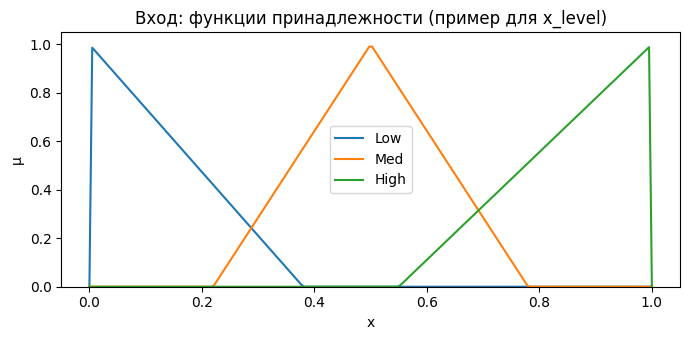

criticality: min / median / max
0.0376 0.060000000000000005 0.8458097928436911


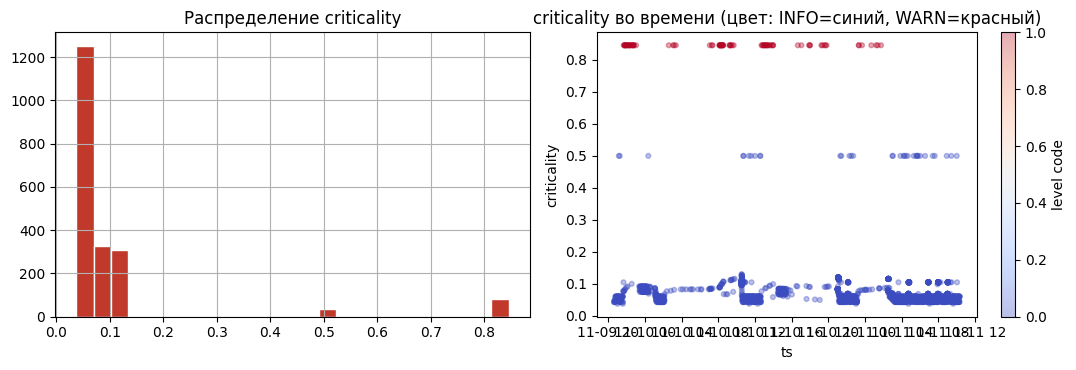


Топ-10 по criticality:


,ts,criticality,level,event_type,x_level,x_kb_base,x_lex,x_ctx,message
332,2008-11-10 08:16:43,0.84581,WARN,warn_exception_serving,0.72,0.95,1.0,0.140000,10.250.17.225:50010:Got exception while servin...
93,2008-11-09 22:20:41,0.84581,WARN,warn_exception_serving,0.72,0.95,1.0,0.138298,10.251.67.113:50010:Got exception while servin...
798,2008-11-10 19:20:15,0.84581,WARN,warn_exception_serving,0.72,0.95,1.0,0.090000,10.250.10.223:50010:Got exception while servin...
797,2008-11-10 19:14:03,0.84581,WARN,warn_exception_serving,0.72,0.95,1.0,0.080000,10.250.14.196:50010:Got exception while servin...
794,2008-11-10 17:59:34,0.84581,WARN,warn_exception_serving,0.72,0.95,1.0,0.090000,10.251.107.50:50010:Got exception while servin...
102,2008-11-09 23:01:10,0.84581,WARN,warn_exception_serving,0.72,0.95,1.0,0.210000,10.251.90.134:50010:Got exception while servin...
101,2008-11-09 22:47:41,0.84581,WARN,warn_exception_serving,0.72,0.95,1.0,0.200000,10.251.35.1:50010:Got exception while serving ...
100,2008-11-09 22:44:20,0.84581,WARN,warn_exception_serving,0.72,0.95,1.0,0.190000,10.251.73.188:50010:Got exception while servin...
99,2008-11-09 22:42:34,0.84581,WARN,warn_exception_serving,0.72,0.95,1.0,0.180000,10.251.73.220:50010:Got exception while servin...
98,2008-11-09 22:40:54,0.84581,WARN,warn_exception_serving,0.72,0.95,1.0,0.171717,10.251.126.255:50010:Got exception while servi...


In [17]:
import numpy as np
import matplotlib.pyplot as plt

need = {"x_level", "x_kb_base", "x_lex", "x_ctx", "x_param"}
if not need.issubset(set(df.columns)):
    raise RuntimeError("Сначала выполните шаг 3 — должны быть столбцы " + ", ".join(sorted(need)))

# --- треугольная μ на [0,1] для входов ---
IN_LOW = (0.0, 0.0, 0.38)
IN_MED = (0.22, 0.5, 0.78)
IN_HIGH = (0.55, 1.0, 1.0)


def trimf_scalar(x: float, abc: tuple[float, float, float]) -> float:
    a, b, c = abc
    x = float(np.clip(x, 0.0, 1.0))
    if x <= a or x >= c:
        return 0.0
    if x < b:
        return 0.0 if b == a else (x - a) / (b - a)
    return 0.0 if c == b else (c - x) / (c - b)


def trimf_vec(z: np.ndarray, abc: tuple[float, float, float]) -> np.ndarray:
    a, b, c = abc
    y = np.zeros_like(z, dtype=float)
    m1 = (z >= a) & (z <= b)
    m2 = (z >= b) & (z <= c)
    y[m1] = (z[m1] - a) / max(b - a, 1e-9)
    y[m2] = (c - z[m2]) / max(c - b, 1e-9)
    return np.clip(y, 0.0, 1.0)


# универсум ответа (критичность)
z = np.linspace(0.0, 1.0, 121)
OUT_LOW = trimf_vec(z, (0.0, 0.0, 0.38))
OUT_MED = trimf_vec(z, (0.25, 0.5, 0.75))
OUT_HIGH = trimf_vec(z, (0.55, 1.0, 1.0))

# иллюстрация входных термов
fig, ax = plt.subplots(figsize=(7, 3.5))
t = np.linspace(0, 1, 200)
ax.plot(t, [trimf_scalar(x, IN_LOW) for x in t], label="Low")
ax.plot(t, [trimf_scalar(x, IN_MED) for x in t], label="Med")
ax.plot(t, [trimf_scalar(x, IN_HIGH) for x in t], label="High")
ax.set_title("Вход: функции принадлежности (пример для x_level)")
ax.set_xlabel("x")
ax.set_ylabel("μ")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


def criticality_mamdani(xl: float, xkb: float, xlex: float, xctx: float, xpar: float) -> float:
    # термы
    L_l, M_l, H_l = trimf_scalar(xl, IN_LOW), trimf_scalar(xl, IN_MED), trimf_scalar(xl, IN_HIGH)
    L_k, M_k, H_k = trimf_scalar(xkb, IN_LOW), trimf_scalar(xkb, IN_MED), trimf_scalar(xkb, IN_HIGH)
    L_x, M_x, H_x = trimf_scalar(xlex, IN_LOW), trimf_scalar(xlex, IN_MED), trimf_scalar(xlex, IN_HIGH)
    L_c, M_c, H_c = trimf_scalar(xctx, IN_LOW), trimf_scalar(xctx, IN_MED), trimf_scalar(xctx, IN_HIGH)
    L_p, M_p, H_p = trimf_scalar(xpar, IN_LOW), trimf_scalar(xpar, IN_MED), trimf_scalar(xpar, IN_HIGH)

    agg = np.zeros_like(z)

    # R1: высокий уровень лога ИЛИ лексика «плохая» -> высокая критичность
    a = max(H_l, H_x)
    agg = np.maximum(agg, np.minimum(a, OUT_HIGH))

    # R2: база знаний считает тип тяжёлым -> высокая критичность
    a = H_k
    agg = np.maximum(agg, np.minimum(a, OUT_HIGH))

    # R3: всплеск WARN в окне -> хотя бы средняя критичность
    a = H_c
    agg = np.maximum(agg, np.minimum(a, OUT_MED))

    # R4: параметры (размер блока) сильно нестандартные -> средняя+
    a = H_p
    agg = np.maximum(agg, np.minimum(a, OUT_MED))

    # R5: всё «тихо» -> низкая критичность
    a = min(L_l, L_k, L_x, L_c, L_p)
    agg = np.maximum(agg, np.minimum(a, OUT_LOW))

    s = agg.sum()
    if s < 1e-9:
        return float(np.clip(0.22 * xl + 0.28 * xkb + 0.35 * xlex + 0.15 * xctx + 0.1 * xpar, 0, 1))
    return float(np.sum(z * agg) / s)


crit = []
for row in df.itertuples(index=False):
    crit.append(
        criticality_mamdani(row.x_level, row.x_kb_base, row.x_lex, row.x_ctx, row.x_param)
    )
df["criticality"] = crit

print("criticality: min / median / max")
print(df["criticality"].min(), df["criticality"].median(), df["criticality"].max())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
df["criticality"].hist(bins=25, ax=axes[0], color="#c0392b", edgecolor="white")
axes[0].set_title("Распределение criticality")
sc = axes[1].scatter(df["ts"], df["criticality"], c=df["level"].map({"INFO": 0, "WARN": 1}).fillna(0), cmap="coolwarm", alpha=0.35, s=12)
axes[1].set_title("criticality во времени (цвет: INFO=синий, WARN=красный)")
axes[1].set_xlabel("ts")
axes[1].set_ylabel("criticality")
plt.colorbar(sc, ax=axes[1], label="level code")
plt.tight_layout()
plt.show()

print("\nТоп-10 по criticality:")
display(
    df.sort_values("criticality", ascending=False)
    .head(10)[["ts", "criticality", "level", "event_type", "x_level", "x_kb_base", "x_lex", "x_ctx", "message"]]
)

## Шаг 5. Проверка черновой модели и экспорт

Смысл шага: убедиться, что **`criticality` согласуется с интуицией** (например, `warn_exception_serving` и `WARN` выше «фона»), и зафиксировать результат в файле для отчёта или доработки правил.

- средняя / медианная критичность по **`event_type`** и по **`level`**;
- простая **матрица ошибок** при пороге (здесь `WARN` временно считаем «истинной тревогой»);
- сохранение **`outputs/criticality_scores.csv`** (основные столбцы).

Критичность по event_type (mean ↑):


,count,mean,median
event_type,,,
packet_responder_terminating,311,0.047059,0.04320
verification_succeeded,20,0.051400,0.05035
allocate_block,115,0.052700,0.04880
block_receiving,292,0.064716,0.06000
add_stored_block,314,0.081356,0.04880
other,231,0.081523,0.07890
block_received,294,0.084308,0.06000
block_served,80,0.089022,0.08655
deleting_block,263,0.109494,0.10480


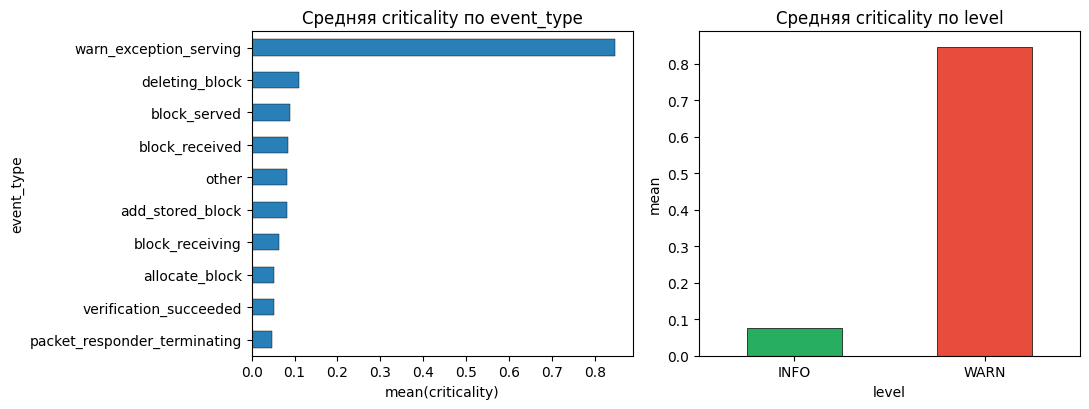

Тип с максимальной средней criticality: warn_exception_serving (mean=0.8458)

Порог criticality >= 0.1198 (квантиль 0.92 по всем строкам)
Матрица: pred=высокая критичность, actual=WARN
TP=80 FP=82 FN=0 TN=1838
Precision≈0.494  Recall≈1.000

Сохранено: /Users/musazarifanov/Desktop/LogFuzzy/outputs/criticality_scores.csv (2000 строк, 13 колонок)


In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if "criticality" not in df.columns:
    raise RuntimeError("Сначала выполните шаг 4 — должен появиться столбец criticality.")

# --- сводка по типам событий ---
by_evt = (
    df.groupby("event_type", observed=True)["criticality"]
    .agg(count="count", mean="mean", median="median")
    .sort_values("mean")
)
print("Критичность по event_type (mean ↑):")
display(by_evt)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
by_evt["mean"].plot(kind="barh", ax=axes[0], color="#2980b9", edgecolor="black", linewidth=0.3)
axes[0].set_title("Средняя criticality по event_type")
axes[0].set_xlabel("mean(criticality)")

by_lvl = df.groupby("level", observed=True)["criticality"].mean().reindex(["INFO", "WARN", "ERROR", "DEBUG", "FATAL"]).dropna()
by_lvl.plot(kind="bar", ax=axes[1], color=["#27ae60", "#e74c3c"][: len(by_lvl)], edgecolor="black", linewidth=0.5)
axes[1].set_title("Средняя criticality по level")
axes[1].set_ylabel("mean")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

# интуиция: самый высокий mean должен быть у warn / warn_exception_serving
top_evt = by_evt["mean"].idxmax()
print("Тип с максимальной средней criticality:", top_evt, f"(mean={by_evt.loc[top_evt, 'mean']:.4f})")

# --- порог: WARN как «позитивный класс» (учебная оценка) ---
TH = float(np.quantile(df["criticality"], 0.92))
pred = df["criticality"] >= TH
actual = df["level"].eq("WARN")
tp = int((pred & actual).sum())
fp = int((pred & ~actual).sum())
fn = int((~pred & actual).sum())
tn = int((~pred & ~actual).sum())
prec = tp / (tp + fp) if (tp + fp) else 0.0
rec = tp / (tp + fn) if (tp + fn) else 0.0
print(f"\nПорог criticality >= {TH:.4f} (квантиль 0.92 по всем строкам)")
print("Матрица: pred=высокая критичность, actual=WARN")
print(f"TP={tp} FP={fp} FN={fn} TN={tn}")
print(f"Precision≈{prec:.3f}  Recall≈{rec:.3f}")

# --- экспорт ---
out_dir = Path("outputs")
out_dir.mkdir(parents=True, exist_ok=True)
export_cols = [
    "ts",
    "date",
    "time",
    "level",
    "component",
    "event_type",
    "criticality",
    "x_level",
    "x_kb_base",
    "x_lex",
    "x_ctx",
    "x_param",
    "message",
]
cols_ok = [c for c in export_cols if c in df.columns]
df[cols_ok].to_csv(out_dir / "criticality_scores.csv", index=False)
print("\nСохранено:", out_dir.resolve() / "criticality_scores.csv", f"({len(df)} строк, {len(cols_ok)} колонок)")

## Шаг 6. ROC / PR и выбор порога (прокси: `WARN`)

**Важно:** в реальных логах `WARN` — не полная «истина», а удобная **прокси-разметка** для отладки скоринга.

Здесь:
- строим **ROC** и **PR** кривые для пары `(y_true = WARN, score = criticality)`;
- считаем **AUC-ROC** и **Average Precision** (AP);
- подбираем порог двумя эвристиками: **максимум F1** на сетке и **Youden J** на ROC (`TPR - FPR`).

AUC-ROC = 1.0000
Average Precision (AP) = 1.0000
Порог по Youden J: 0.8458  (Jmax=1.0000)
Порог по max F1 на сетке [0,1]: 0.5020  (F1≈1.0000)


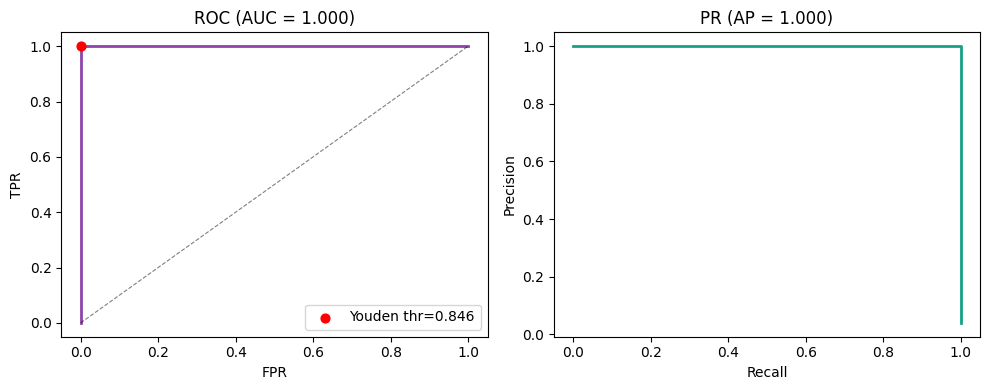


Youden (thr=0.8458): TP=80 FP=0 FN=0 TN=1920
  precision 1.000  recall 1.000

Max F1 (thr=0.5020): TP=80 FP=0 FN=0 TN=1920
  precision 1.000  recall 1.000


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    auc,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_curve,
)

if "criticality" not in df.columns:
    raise RuntimeError("Нужен столбец criticality (шаг 4).")

y_true = df["level"].eq("WARN").astype(int).to_numpy()
y_score = df["criticality"].to_numpy(dtype=float)
_bad_score = ~np.isfinite(y_score)
if _bad_score.any():
    print(
        f"Внимание: {_bad_score.sum()} строк с NaN/inf в criticality — для ROC/PR подставлена медиана."
    )
    _med = float(np.nanmedian(y_score))
    y_score = np.where(np.isfinite(y_score), y_score, _med)

if y_true.sum() == 0 or y_true.sum() == len(y_true):
    print("WARN отсутствует или все строки WARN — ROC/PR неинформативны.")
else:
    fpr, tpr, thr_roc = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    prec, rec, thr_pr = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    # Youden J
    j = tpr - fpr
    ix = int(np.argmax(j))
    thr_j = float(thr_roc[ix])

    # F1 на равномерной сетке порогов
    grid = np.linspace(0, 1, 501)
    best_f1, thr_f1 = 0.0, 0.5
    for t in grid:
        pred = (y_score >= t).astype(int)
        f = f1_score(y_true, pred, zero_division=0)
        if f > best_f1:
            best_f1, thr_f1 = f, float(t)

    print(f"AUC-ROC = {roc_auc:.4f}")
    print(f"Average Precision (AP) = {ap:.4f}")
    print(f"Порог по Youden J: {thr_j:.4f}  (Jmax={j[ix]:.4f})")
    print(f"Порог по max F1 на сетке [0,1]: {thr_f1:.4f}  (F1≈{best_f1:.4f})")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(fpr, tpr, color="#8e44ad", lw=2)
    axes[0].plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
    axes[0].scatter([fpr[ix]], [tpr[ix]], color="red", s=40, zorder=5, label=f"Youden thr={thr_j:.3f}")
    axes[0].set_title(f"ROC (AUC = {roc_auc:.3f})")
    axes[0].set_xlabel("FPR")
    axes[0].set_ylabel("TPR")
    axes[0].legend(loc="lower right")

    axes[1].plot(rec, prec, color="#16a085", lw=2)
    axes[1].set_title(f"PR (AP = {ap:.3f})")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    plt.tight_layout()
    plt.show()

    def show_cm(threshold: float, name: str):
        pred = (y_score >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
        print(f"\n{name} (thr={threshold:.4f}): TP={tp} FP={fp} FN={fn} TN={tn}")
        print(
            "  precision",
            f"{tp/(tp+fp):.3f}" if (tp + fp) else "  n/a",
            " recall",
            f"{tp/(tp+fn):.3f}" if (tp + fn) else "  n/a",
        )

    show_cm(thr_j, "Youden")
    show_cm(thr_f1, "Max F1")